### ROC Curve   

In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
x = data.drop('Outcome',axis=1)
y = data['Outcome']

In [4]:
x.shape

(768, 8)

In [5]:
y.shape

(768,)

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [7]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [8]:
lr.fit(x_train,y_train)

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred = lr.predict(x_test)

In [11]:
y_score = lr.predict_proba(x_test)[:,1]

In [14]:
y_score.shape

(231,)

In [21]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_test,y_score)

In [22]:
fpr

array([0.        , 0.        , 0.00662252, 0.00662252, 0.01324503,
       0.01324503, 0.01986755, 0.01986755, 0.02649007, 0.02649007,
       0.0397351 , 0.0397351 , 0.04635762, 0.04635762, 0.05298013,
       0.05298013, 0.06622517, 0.06622517, 0.07284768, 0.07284768,
       0.08609272, 0.08609272, 0.09271523, 0.09271523, 0.09933775,
       0.09933775, 0.1192053 , 0.1192053 , 0.13245033, 0.13245033,
       0.1589404 , 0.1589404 , 0.17880795, 0.17880795, 0.18543046,
       0.18543046, 0.1986755 , 0.1986755 , 0.20529801, 0.20529801,
       0.2384106 , 0.2384106 , 0.27152318, 0.27152318, 0.2781457 ,
       0.2781457 , 0.29801325, 0.29801325, 0.30463576, 0.30463576,
       0.31125828, 0.31125828, 0.31788079, 0.31788079, 0.34437086,
       0.34437086, 0.36423841, 0.36423841, 0.37086093, 0.37086093,
       0.39735099, 0.39735099, 0.40397351, 0.40397351, 0.43708609,
       0.43708609, 0.45033113, 0.45033113, 0.46357616, 0.46357616,
       0.47682119, 0.47682119, 0.50993377, 0.50993377, 0.52317

In [23]:
tpr

array([0.    , 0.0125, 0.0125, 0.0625, 0.0625, 0.1125, 0.1125, 0.225 ,
       0.225 , 0.25  , 0.25  , 0.2625, 0.2625, 0.3375, 0.3375, 0.375 ,
       0.375 , 0.4125, 0.4125, 0.425 , 0.425 , 0.5   , 0.5   , 0.5125,
       0.5125, 0.525 , 0.525 , 0.5375, 0.5375, 0.575 , 0.575 , 0.5875,
       0.5875, 0.6   , 0.6   , 0.6125, 0.6125, 0.625 , 0.625 , 0.6375,
       0.6375, 0.6625, 0.6625, 0.675 , 0.675 , 0.6875, 0.6875, 0.7   ,
       0.7   , 0.7125, 0.7125, 0.7375, 0.7375, 0.7625, 0.7625, 0.775 ,
       0.775 , 0.7875, 0.7875, 0.8   , 0.8   , 0.8125, 0.8125, 0.825 ,
       0.825 , 0.8375, 0.8375, 0.8625, 0.8625, 0.8875, 0.8875, 0.9   ,
       0.9   , 0.9125, 0.9125, 0.925 , 0.925 , 0.9375, 0.9375, 0.95  ,
       0.95  , 0.9625, 0.9625, 0.975 , 0.975 , 0.9875, 0.9875, 1.    ,
       1.    ])

In [24]:
thresholds

array([       inf, 0.96767656, 0.96396611, 0.90097261, 0.90039113,
       0.88059924, 0.87978396, 0.82376691, 0.80936328, 0.80262966,
       0.79311883, 0.79075045, 0.7900424 , 0.77091721, 0.76554869,
       0.74834965, 0.74223135, 0.72446795, 0.72432712, 0.70749632,
       0.69558242, 0.65924756, 0.64860506, 0.64426402, 0.64379525,
       0.64361452, 0.62303381, 0.6210243 , 0.6164613 , 0.59358128,
       0.55426656, 0.54975669, 0.53954554, 0.52928538, 0.52272974,
       0.51380377, 0.50574202, 0.50433846, 0.496113  , 0.48807297,
       0.44582242, 0.41388388, 0.392251  , 0.38441557, 0.36633624,
       0.35980696, 0.34548552, 0.34537524, 0.34511083, 0.343842  ,
       0.33659641, 0.32078016, 0.31917833, 0.31343363, 0.29633778,
       0.29070764, 0.27617356, 0.27292868, 0.27100984, 0.26732851,
       0.26308519, 0.26130125, 0.25891903, 0.2586801 , 0.24615158,
       0.23981668, 0.22945764, 0.22811342, 0.2199516 , 0.21708936,
       0.2110112 , 0.20603581, 0.18172666, 0.17304895, 0.16501

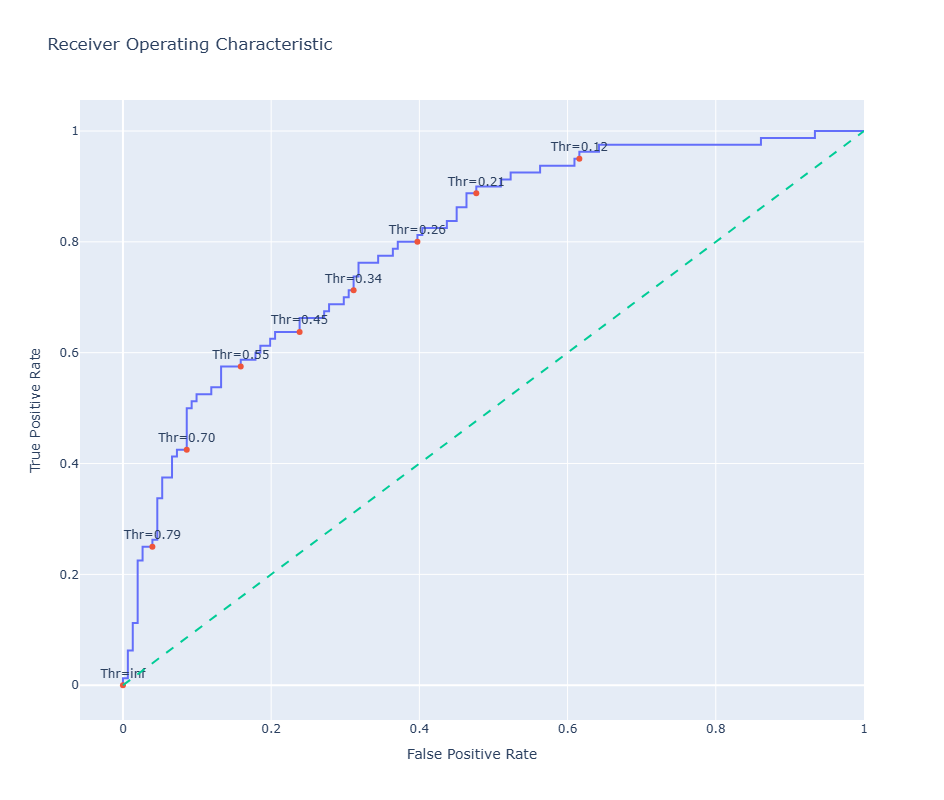

In [25]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


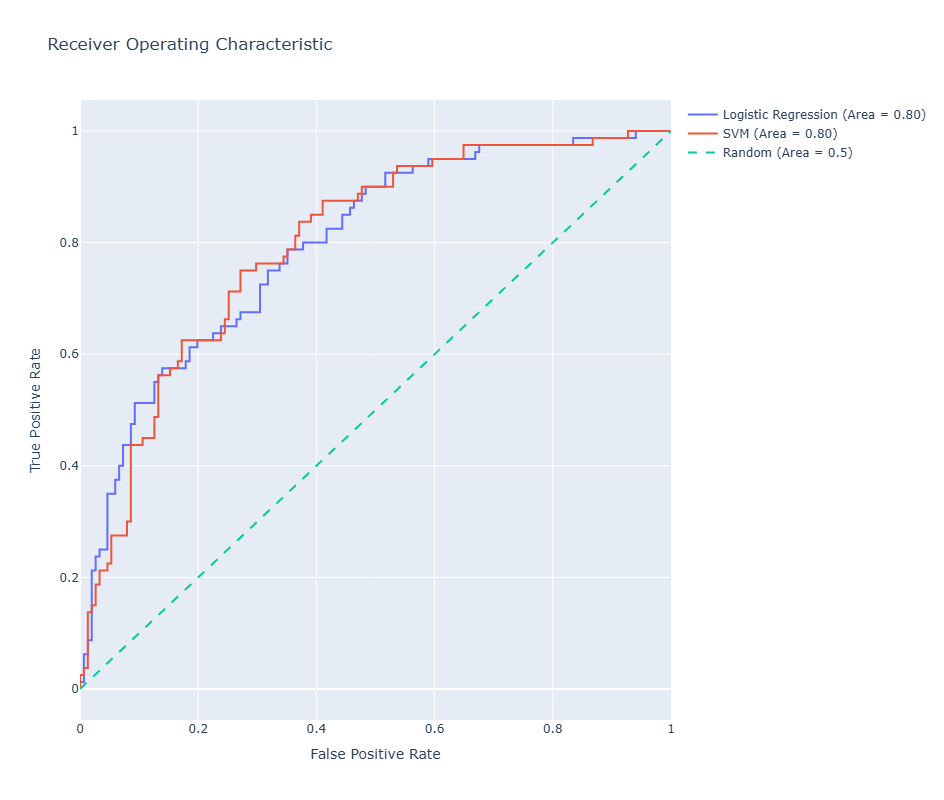

In [29]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train, y_train)
lr_scores = lr_model.predict_proba(x_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(x_train_scaled, y_train)
svm_scores = svm_model.predict_proba(x_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()
